# Loading

In [18]:
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.sandwich_covariance import cov_cluster
import numpy as np
import os
from tqdm import tqdm
import gc
from numba import njit
import duckdb
# Basic Models with just phase interaction
import sys
import statsmodels.formula.api as smf
from statsmodels.stats.sandwich_covariance import cov_cluster
from IPython.display import HTML
import numpy as np
import pandas as pd
from stargazer.stargazer import Stargazer

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

required_columns = [
    'numHelped',
    'phase',
    'hasAnswer',
    'userId',
    'userFeNumHelped',
    'numHelpProvidedAT',
    'userFeNumQuestionsAskedAT',
    'userFeNumHelpProvidedAT',
    'numQuestionsAskedAT',
    'logNumHelpProvidedAT',
    'logNumQuestionsAskedAT',
    'timeSinceFirstActivityDays',
    'userFeLogNumHelpProvidedAT',
    'userFeLogNumQuestionsAskedAT',
    'year',
]

df_reciprocity = pd.read_parquet('../data/study_datasets/question_centered_model_7d.parquet',
                    columns=required_columns)

df_reciprocity['numQnAAT'] = df_reciprocity['numQuestionsAskedAT'] + df_reciprocity['numHelpProvidedAT']

required_columns = [
    'isBounty',
    'userFEIsBounty',
    'userId',
    'timeSinceFirstActivityDays',
    'logtimeSinceFirstActivityDays',
    'userFeLogTimeSinceFirstActivityDays',
    'numHelpProvidedAT',
    'numQuestionsAskedAT',
    'logNumHelpProvidedAT',
    'logNumQuestionsAskedAT',
    'userFeLogNumHelpProvidedAT',
    'userFeLogNumQuestionsAskedAT',
    'year',
]

df_bounty = pd.read_parquet('../data/study_datasets/user_answers_bounty_processed_dateFiltered.parquet', columns=required_columns)
df_bounty['numQnAAT'] = df_bounty['numQuestionsAskedAT'] + df_bounty['numHelpProvidedAT']

# Filter and Re-calculate FEs

In [19]:
def filter_users_by_help_threshold(df, cutoff=5, verbose=True):
    """
    Filter dataset to users who have provided at least 'cutoff' help at some point,
    then keep only events where numHelpProvidedAT <= cutoff.
    """
        # Find users with max help >= cutoff
    user_max_help = df.groupby('userId')['numQnAAT'].max()
    included_users = user_max_help[user_max_help >= cutoff].index.tolist()

    # Filter to these users and events <= cutoff
    filtered_df = df[
        (df['userId'].isin(included_users)) &
        (df['numQnAAT'] <= cutoff)
    ].copy()

    if verbose:
        print(f"Cutoff: {cutoff}")
        print(f"Users included: {len(included_users):,}")
        print(f"Events: {len(filtered_df):,} ({len(filtered_df)/len(df):.1%} of original)")

    return filtered_df

print("=== RECIPROCITY DATASET ===")
df_reciprocity_filtered = filter_users_by_help_threshold(df_reciprocity, cutoff=5)
df_reciprocity_filtered['userFeNumHelped'] = df_reciprocity_filtered.groupby("userId")["numHelped"].transform(lambda x: x - x.mean())

print("\n=== BOUNTY DATASET ===")
df_bounty_filtered = filter_users_by_help_threshold(df_bounty, cutoff=5)
df_bounty_filtered['userFEIsBounty'] = df_bounty_filtered.groupby("userId")["isBounty"].transform(lambda x: x - x.mean())

import gc
del df_reciprocity, df_bounty
gc.collect()

=== RECIPROCITY DATASET ===
Cutoff: 5
Users included: 1,053,845
Events: 9,691,632 (20.4% of original)

=== BOUNTY DATASET ===
Cutoff: 5
Users included: 873,338
Events: 2,984,399 (9.1% of original)


0

In [20]:
df_reciprocity_filtered.to_parquet('../data/study_datasets/question_centered_model_7d_5_bins.parquet', index=False)
df_bounty_filtered.to_parquet('../data/study_datasets/user_answers_bounty_processed_5_bins.parquet', index=False)

In [1]:
import pandas as pd
import numpy as np
df_rec = pd.read_parquet('../data/study_datasets/question_centered_model_7d_5_bins.parquet')
df_rec['logtimeSinceFirstActivityDays'] = np.log(1 + df_rec['timeSinceFirstActivityDays'])
df_bounty = pd.read_parquet('../data/study_datasets/user_answers_bounty_processed_5_bins.parquet')
df_bounty['logtimeSinceFirstActivityDays'] = np.log(1 + df_bounty['timeSinceFirstActivityDays'])

# 1. Plot Comparing

## 1.1 Reciprocity

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df_rec['phase'] = df_rec['phase'].astype(str)
df_rec['hasAnswer'] = df_rec['hasAnswer'].astype(str)
df_rec['numQnAAT'] = df_rec['numQnAAT'].astype(str)

formula = """userFeNumHelped ~ C(phase)*C(hasAnswer)*C(numQnAAT) + logtimeSinceFirstActivityDays + C(year)"""

# Fit the logistic model using the formula and clustered standard errors
model = smf.ols(formula=formula, data=df_rec).fit(cov_type='cluster', cov_kwds={'groups': df_rec['userId']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        userFeNumHelped   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     535.0
Date:                Mon, 23 Jun 2025   Prob (F-statistic):               0.00
Time:                        20:41:18   Log-Likelihood:            -1.2958e+07
No. Observations:             9691632   AIC:                         2.592e+07
Df Residuals:                 9691590   BIC:                         2.592e+07
Df Model:                          41                                         
Covariance Type:              cluster                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Plot saved successfully as ../plots/reciprocity_by_numQnAAT.eps


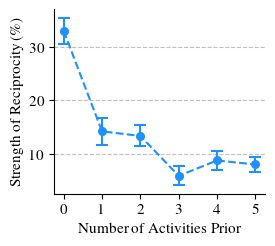

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

def set_size(width=433.62, fraction=1, height_scale=1.0, equal_height_to_fraction_1=False):
    """
    Set figure dimensions to avoid scaling in LaTeX.
    (This function is unchanged from your provided code)
    """
    fig_width_pt = width * fraction
    inches_per_pt = 1 / 72.27
    fig_width_in = fig_width_pt * inches_per_pt
    golden_ratio = (5**0.5 - 1) / 2
    if equal_height_to_fraction_1:
        base_height_in = (width * inches_per_pt) * golden_ratio
    else:
        base_height_in = fig_width_in * golden_ratio
    fig_height_in = base_height_in * height_scale
    return (fig_width_in, fig_height_in)

def create_plot_numQnAAT_effect_styled(model, df):
    """
    Creates a plot for the numQnAAT interaction effect, styled to match
    the reference plot design.

    This function assumes the model formula was:
    'userFeNumHelped ~ C(phase)*C(hasAnswer)*C(numQnAAT) + ...'

    Parameters:
    ----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        The fitted OLS model object from your first analysis.
    df : pd.DataFrame
        The DataFrame used to fit the model (e.g., 'df_rec'), required for
        calculating the mean of the dependent variable for normalization.
    """
    # =============================================================================
    # 1. Define and Extract Coefficients
    # =============================================================================
    try:
        ref_coef_name = 'C(phase)[T.2]:C(hasAnswer)[T.1]'
        interaction_coef_names = {
            i: f'C(phase)[T.2]:C(hasAnswer)[T.1]:C(numQnAAT)[T.{i}]'
            for i in range(1, 6)
        }
        params = model.params
        vcov = model.cov_params()

    except KeyError as e:
        print(f"Error: A coefficient name was not found in the model results: {e}")
        print("Please ensure the model being passed was fitted with the formula:")
        print("'userFeNumHelped ~ C(phase)*C(hasAnswer)*C(numQnAAT) + ...'")
        return

    # =============================================================================
    # 2. Calculate Combined Effects & Standard Errors
    # =============================================================================
    effects = {}
    std_errors = {}

    # --- Baseline (numQnAAT = 0) ---
    effects[0] = params[ref_coef_name]
    std_errors[0] = model.bse[ref_coef_name]

    # --- Interaction levels (numQnAAT = 1 to 5) ---
    for i in range(1, 6):
        interaction_name = interaction_coef_names[i]
        effects[i] = params[ref_coef_name] + params[interaction_name]
        var_ref = vcov.loc[ref_coef_name, ref_coef_name]
        var_interaction = vcov.loc[interaction_name, interaction_name]
        cov_ref_interaction = vcov.loc[ref_coef_name, interaction_name]
        std_errors[i] = np.sqrt(var_ref + var_interaction + 2 * cov_ref_interaction)

    # =============================================================================
    # 3. Normalize to Percentage and Generate Plot
    # =============================================================================
    pop_mean_dependent_var = df['numHelped'].mean()
    if pop_mean_dependent_var == 0:
        print("Warning: Mean of dependent variable 'userFeNumHelped' is zero. Using 1 to avoid division by zero.")
        pop_mean_dependent_var = 1

    plot_data = pd.DataFrame({
        'numQnAAT': list(effects.keys()),
        'Effect': list(effects.values()),
        'StdError': list(std_errors.values())
    })
    plot_data['Effect_Percent'] = (plot_data['Effect'] / pop_mean_dependent_var) * 100
    plot_data['StdError_Percent'] = (plot_data['StdError'] / pop_mean_dependent_var) * 100

    # =============================================================================
    # 4. Plot Generation with Specific Styling
    # =============================================================================
    plt.rcParams['text.latex.preamble'] = r"\usepackage{txfonts}"
    params = {'text.usetex': True, 'font.size': 11, 'font.family': 'serif'}
    plt.rcParams.update(params)

    # Use exact figsize settings from the reference plot
    fig, ax = plt.subplots(figsize=set_size(fraction=0.48, height_scale=0.7, equal_height_to_fraction_1=True))

    # Use exact errorbar settings from the reference plot
    ax.errorbar(
        x=plot_data['numQnAAT'],
        y=plot_data['Effect_Percent'],
        yerr=plot_data['StdError_Percent'],
        marker='o',              # Use a dot for the effect size
        linestyle='--',         # Connect dots with a dashed line
        capsize=4,               # Size of the error bar caps
        color='dodgerblue',      # Color for the line, markers, and error bars
        elinewidth=1.5,          # Thickness of the error bar lines
        markeredgewidth=1.5,     # Edge thickness of the markers
        markersize=5             # Size of the markers
    )

    # --- Formatting copied from reference plot ---
    # NOTE: You may need to adjust ylim based on your new data's range.
    # ax.set_ylim(-25, 15)
    ax.set_ylabel(r'Strength of Reciprocity (\%)')
    ax.set_xlabel(r'Number of Activities Prior') # Adjusted for the new x-axis
    # ax.axhline(0, color='black', linewidth=0.8) # Solid horizontal line
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', which='major', color='gray', alpha=0.5)
    ax.set_axisbelow(True)

    # Set x-axis ticks to be integers for clarity
    ax.set_xticks(range(6))
    ax.set_xticklabels(range(6))

    fig.tight_layout()

    # --- Save and Show Plot ---
    output_filename = "../plots/reciprocity_by_numQnAAT.eps"
    plt.savefig(output_filename, format='eps', dpi=1000, bbox_inches='tight')
    print(f"\nPlot saved successfully as {output_filename}")
    plt.show()

create_plot_numQnAAT_effect_styled(model=model, df=df_rec)

## Status Motives

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df_bounty['numQnAAT'] = df_bounty['numQnAAT'].astype(str)

formula = """userFEIsBounty ~ C(numQnAAT) + logtimeSinceFirstActivityDays + C(year)"""

# Fit the logistic model using the formula and clustered standard errors
model_status = smf.ols(formula=formula, data=df_bounty).fit(cov_type='cluster', cov_kwds={'groups': df_bounty['userId']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        userFeNumHelped   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     535.0
Date:                Mon, 23 Jun 2025   Prob (F-statistic):               0.00
Time:                        20:42:26   Log-Likelihood:            -1.2958e+07
No. Observations:             9691632   AIC:                         2.592e+07
Df Residuals:                 9691590   BIC:                         2.592e+07
Df Model:                          41                                         
Covariance Type:              cluster                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Plot saved successfully as ../plots/status_by_numQnAAT.eps


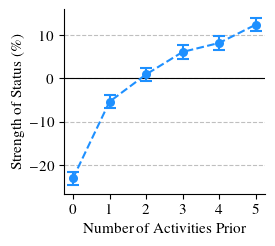

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

def set_size(width=433.62, fraction=1, height_scale=1.0, equal_height_to_fraction_1=False):
    """
    Set figure dimensions to avoid scaling in LaTeX.
    (This function is unchanged)
    """
    fig_width_pt = width * fraction
    inches_per_pt = 1 / 72.27
    fig_width_in = fig_width_pt * inches_per_pt
    golden_ratio = (5**0.5 - 1) / 2
    if equal_height_to_fraction_1:
        base_height_in = (width * inches_per_pt) * golden_ratio
    else:
        base_height_in = fig_width_in * golden_ratio
    fig_height_in = base_height_in * height_scale
    return (fig_width_in, fig_height_in)

def create_plot_status_effect(model, df):
    """
    Creates a plot for the status effect based on numQnAAT.

    This function assumes the model's reference level is the 'Intercept' and
    that the effects of interest are the 'C(numQnAAT)[T.k]' coefficients.
    The effect size is normalized by the mean of the 'isBounty' column.

    Parameters:
    ----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        The fitted OLS model object for the status analysis.
    df : pd.DataFrame
        The DataFrame used to fit the model, which must contain the 'isBounty' column.
    """
    # =============================================================================
    # 1. Define and Extract Coefficients
    # =============================================================================
    try:
        # The reference level effect (for numQnAAT = 0) is the Intercept
        ref_coef_name = 'Intercept'

        # The names for the treatment terms for numQnAAT levels '1' to '5'
        treatment_coef_names = {
            i: f'C(numQnAAT)[T.{i}]'
            for i in range(1, 6)
        }
        params = model.params
        vcov = model.cov_params()

    except KeyError as e:
        print(f"Error: A coefficient name was not found in the model results: {e}")
        print("Please ensure the model being passed includes an Intercept and 'C(numQnAAT)'.")
        return

    # =============================================================================
    # 2. Calculate Combined Effects & Standard Errors
    # =============================================================================
    effects = {}
    std_errors = {}

    # --- Baseline (numQnAAT = 0) is the intercept ---
    effects[0] = params[ref_coef_name]
    std_errors[0] = model.bse[ref_coef_name]

    # --- Other levels (numQnAAT = 1 to 5) ---
    # The effect for each level is the Intercept + the coefficient for that level
    for i in range(1, 6):
        treatment_name = treatment_coef_names[i]
        effects[i] = params[ref_coef_name] + params[treatment_name]

        # Calculate standard error for the sum of two coefficients:
        # SE(A+B) = sqrt(Var(A) + Var(B) + 2*Cov(A,B))
        var_ref = vcov.loc[ref_coef_name, ref_coef_name]
        var_treatment = vcov.loc[treatment_name, treatment_name]
        cov_ref_treatment = vcov.loc[ref_coef_name, treatment_name]
        std_errors[i] = np.sqrt(var_ref + var_treatment + 2 * cov_ref_treatment)

    # =============================================================================
    # 3. Normalize to Percentage and Generate Plot
    # =============================================================================
    # Normalize by the mean of the 'isBounty' column as requested
    pop_mean_bounty = df['isBounty'].mean()
    if pop_mean_bounty == 0:
        print("Warning: Mean of 'isBounty' is zero. Using 1 to avoid division by zero.")
        pop_mean_bounty = 1

    plot_data = pd.DataFrame({
        'numQnAAT': list(effects.keys()),
        'Effect': list(effects.values()),
        'StdError': list(std_errors.values())
    })
    plot_data['Effect_Percent'] = (plot_data['Effect'] / pop_mean_bounty) * 100
    plot_data['StdError_Percent'] = (plot_data['StdError'] / pop_mean_bounty) * 100

    # =============================================================================
    # 4. Plot Generation with Specific Styling
    # =============================================================================
    plt.rcParams['text.latex.preamble'] = r"\usepackage{txfonts}"
    params = {'text.usetex': True, 'font.size': 11, 'font.family': 'serif'}
    plt.rcParams.update(params)

    # Use exact figsize settings from the reference plot
    fig, ax = plt.subplots(figsize=set_size(fraction=0.48, height_scale=0.7, equal_height_to_fraction_1=True))

    # Use exact errorbar settings from the reference plot
    ax.errorbar(
        x=plot_data['numQnAAT'],
        y=plot_data['Effect_Percent'],
        yerr=plot_data['StdError_Percent'],
        marker='o',
        linestyle='--',
        capsize=4,
        color='dodgerblue',
        elinewidth=1.5,
        markeredgewidth=1.5,
        markersize=5
    )

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel(r'Strength of Status (\%)') # New Y-axis label
    ax.set_xlabel(r'Number of Activities Prior') # New X-axis label
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', which='major', color='gray', alpha=0.5)
    ax.set_axisbelow(True)

    # Set x-axis ticks to be integers for clarity
    ax.set_xticks(range(6))
    ax.set_xticklabels(range(6))

    fig.tight_layout()

    # --- Save and Show Plot ---
    output_filename = "../plots/status_by_numQnAAT.eps" # New filename
    plt.savefig(output_filename, format='eps', dpi=1000, bbox_inches='tight')
    print(f"\nPlot saved successfully as {output_filename}")
    plt.show()

create_plot_status_effect(model=model_status, df=df_bounty)